In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from kan import KAN as PyKAN
from sklearn.decomposition import PCA
from torch import nn

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 22})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Using PCA dimensionality reduction to qualitatively estimate the classifier's performance on the unlabeled challenge's test set

## Loading the data set

In [2]:
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv').drop('id', axis=1)
train_y['trq_target'] = train_x['trq_measured'] / (train_y['trq_margin'] / 100 + 1)

train_mean, train_std = train_x.mean(), train_x.std()
train_x = (train_x - train_mean) / train_std
base_features = train_x.columns

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
valid_x = (valid_x - train_mean) / train_std
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
test_x = (test_x - train_mean) / train_std
valid_test_x = pd.concat([valid_x, test_x], ignore_index=True)

In [57]:
def plot_3d_pca(data, loadings, labels, features=base_features, scale=0.5, ax=None, c=None, alpha=0.04, azim=180 + 55,
                only_faulty=False, ):
    for i in range(3):
        data[f'PC{i + 1}'] = data[features].dot(loadings[i, :])

    if ax is None:
        fig = plt.figure(figsize=(20 * scale, 20 * scale))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=25, azim=azim)
        plt.legend(loc="upper right")
        plt.grid(True)

    if c is None:
        c = {0: 'g', 1: 'r'}
    s = 0.5 * 750_000 / len(data)
    for label in [0, 1] if not only_faulty else [1]:
        ax.scatter(
            data[labels == label]['PC1'],
            data[labels == label]['PC2'],
            data[labels == label]['PC3'],
            c=c[label],
            label={0: 'Healthy', 1: 'Faulty'}[label], alpha=alpha, s=s
        )
    return ax

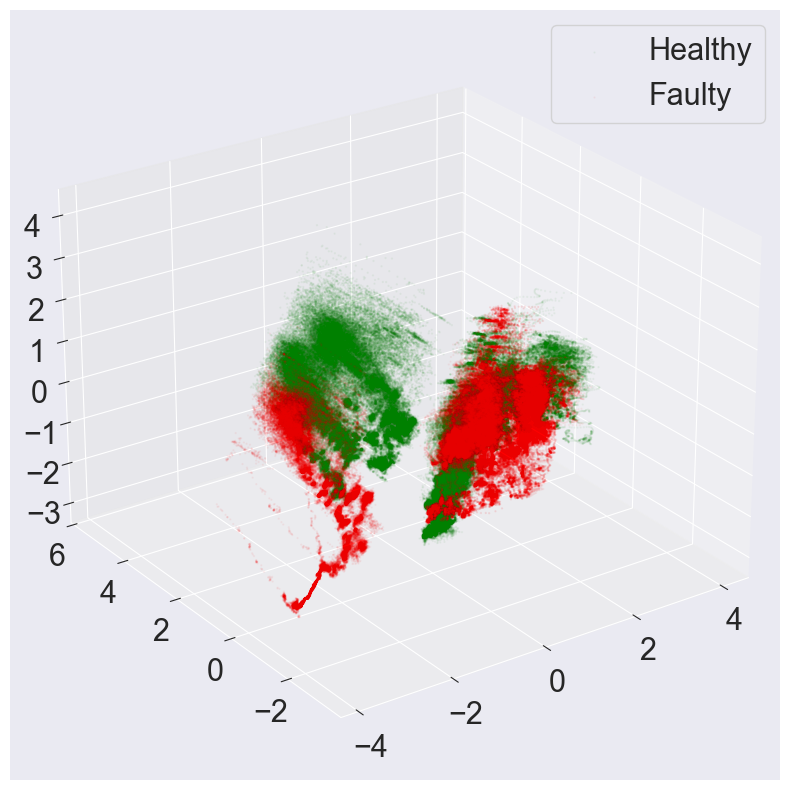

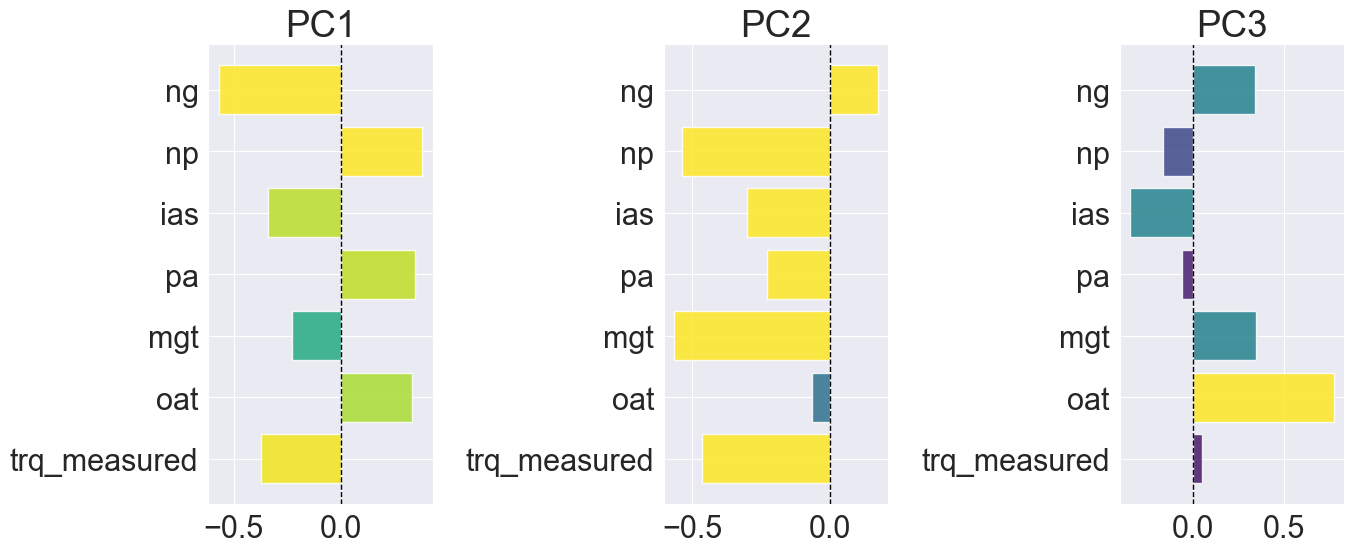

In [29]:
pca = PCA(n_components=len(base_features))
pca.fit_transform(train_x[base_features])
train_loadings = pca.components_[:3]
plot_3d_pca(train_x, train_loadings, train_y['faulty'].values)

# BarH Loadings
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
for i in range(3):
    norm = plt.Normalize(0, max(train_loadings[i]))
    colors = plt.cm.viridis(norm(abs(train_loadings[i])))
    ax[i].barh(base_features, train_loadings[i], color=colors, alpha=0.85)
    ax[i].set_title(f'PC{i + 1}')
    ax[i].axvline(0, color='k', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## Visualizing the valid/test set distribution

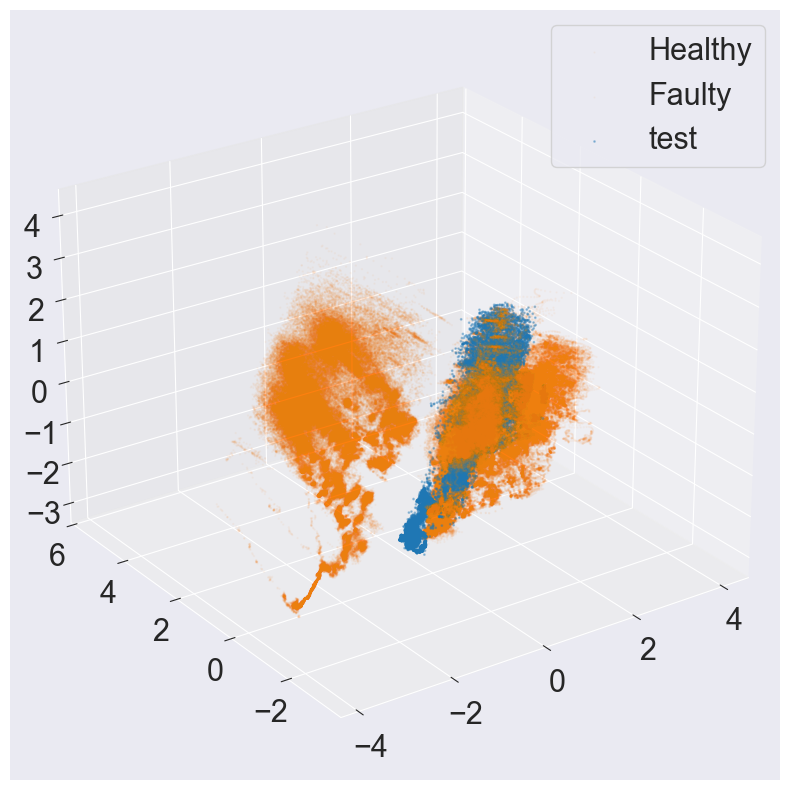

In [104]:
ax = plot_3d_pca(train_x, train_loadings, train_y['faulty'].values, scale=0.5)

for i in range(3):
    valid_test_x[f'PC{i + 1}'] = valid_test_x[base_features].dot(train_loadings[i, :])
ax.scatter(
    valid_test_x['PC1'],
    valid_test_x['PC2'],
    valid_test_x['PC3'],
    c='tab:blue', label='test', alpha=0.35, s=1
)
plt.legend(loc="upper right")
plt.show()

# Predicting the valid/test sets

## Calculating derived features

In [4]:
regression_features = ['trq_measured', 'oat', 'mgt', 'np', 'ng', 'mgt np ng', 'np ng^2', 'trq_measured_norm_da']
classification_features = ['trq_measured', 'oat', 'mgt', 'np', 'ng', 'oat ng^2', 'pa ng^2', 'oat^2 ng', 'mgt_norm_da',
                           'np_air_density']

In [5]:
valid_test_x['mgt np ng'] = valid_test_x['mgt'] * valid_test_x['np'] * valid_test_x['ng']
valid_test_x['np ng^2'] = valid_test_x['np'] * valid_test_x['ng'] ** 2
valid_test_x['oat ng^2'] = valid_test_x['oat'] * valid_test_x['ng'] ** 2
valid_test_x['pa ng^2'] = valid_test_x['pa'] * valid_test_x['ng'] ** 2
valid_test_x['oat^2 ng'] = valid_test_x['oat'] ** 2 * valid_test_x['ng']

valid_test_x['da'] = (1.2376 * valid_test_x['pa']) + (118.8 * (valid_test_x['oat'] + 273.15)) - 1782
valid_test_x['trq_measured_norm_da'] = valid_test_x['trq_measured'] / valid_test_x['da']
valid_test_x['mgt_norm_da'] = valid_test_x['mgt'] / valid_test_x['da']

T0 = 288.15  # Sea-level standard temperature (K)
p0 = 101325  # Sea-level standard atmospheric pressure (Pa)
a = 0.0065  # Temperature lapse rate (K/m)
g = 9.80665  # Gravitational acceleration (m/s^2)
R = 8.3144598  # Universal gas constant (J/(mol·K))
RS = 287.05  # Specific gas constant for air (J/(kg·K))
valid_test_x['h_m'] = valid_test_x['pa'] * 0.3048
valid_test_x['P'] = p0 * (1 - (a * valid_test_x['h_m']) / T0) ** (g / (R * a))
valid_test_x['rho'] = valid_test_x['P'] / (RS * (valid_test_x['oat'] + 273.15))
valid_test_x['np_air_density'] = valid_test_x['np'] / valid_test_x['rho']

In [6]:
class Py_KAN(nn.Module):
    def __init__(self, layers, is_regression, grid_size=3):
        super(Py_KAN, self).__init__()
        self.layers = layers
        self.grid_size = grid_size
        self.is_regression = is_regression
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

    def forward(self, x):
        x = self.model(x)
        if self.is_regression:
            mu = x[:, 0]
            var = x[:, 1]
            return mu, var
        else:
            return x

## Torque Margin estimation

In [7]:
regression_x = valid_test_x[regression_features]

In [ ]:
pyKANReg = Py_KAN(layers=[[len(regression_features), 0], [1, 0], [2, 0]], is_regression=True, grid_size=2)
pyKANReg.model = PyKAN.loadckpt('../2-torque_margin_pdf_regression/models/torque_target_stochastic_small_12-23-01_8.pt')

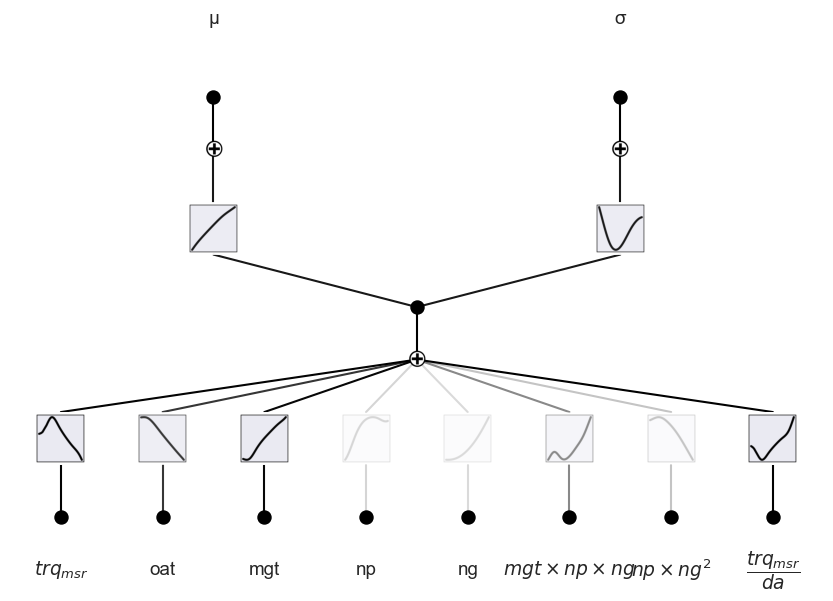

In [9]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$mgt\\times np\\times ng$', '$np\\times ng^2$',
           '$\\dfrac{trq_{msr}}{da}$']
pyKANReg.model.plot(scale=0.75, in_vars=in_vars, out_vars=['μ', 'σ'],
                    varscale=0.45, figsize_base=(14, 10))

In [10]:
pyKANReg.eval()
trq_target_pred = []
mu_mean = train_y['trq_target'].mean()
mu_std = train_y['trq_target'].std()

for i in range(math.ceil(len(regression_x) / 8192)):
    x = regression_x[i * 8192:min(len(regression_x), (i + 1) * 8192)]
    x = torch.tensor(x.values, dtype=torch.float32, device=device)
    mu, _ = pyKANReg(x)
    mu = mu.detach().cpu().numpy() * mu_std + mu_mean  # <-- De-normalization
    trq_target_pred.extend(mu.tolist())
trq_target_pred = pd.Series(trq_target_pred)

In [11]:
de_normalized_trq_measured = regression_x['trq_measured'] * train_std['trq_measured'] + train_mean['trq_measured']
trq_margin_pred = np.where(
    trq_target_pred != 0,
    (de_normalized_trq_measured / trq_target_pred - 1) * 100,
    0
)
trq_margin_pred = pd.Series(trq_margin_pred).replace('unset', 0).astype(float)

## Fault Detection

In [ ]:
classification_x = valid_test_x[classification_features]
classification_x['trq_margin'] = trq_margin_pred

In [ ]:
pyKANClass = Py_KAN(layers=[[len(classification_features), 0], [0, 1], [1, 0]], is_regression=False, grid_size=2)
pyKANClass.model = PyKAN.loadckpt('../3-Fault_Detection/models/fault_detection_multi_23-13-39_8.pt')

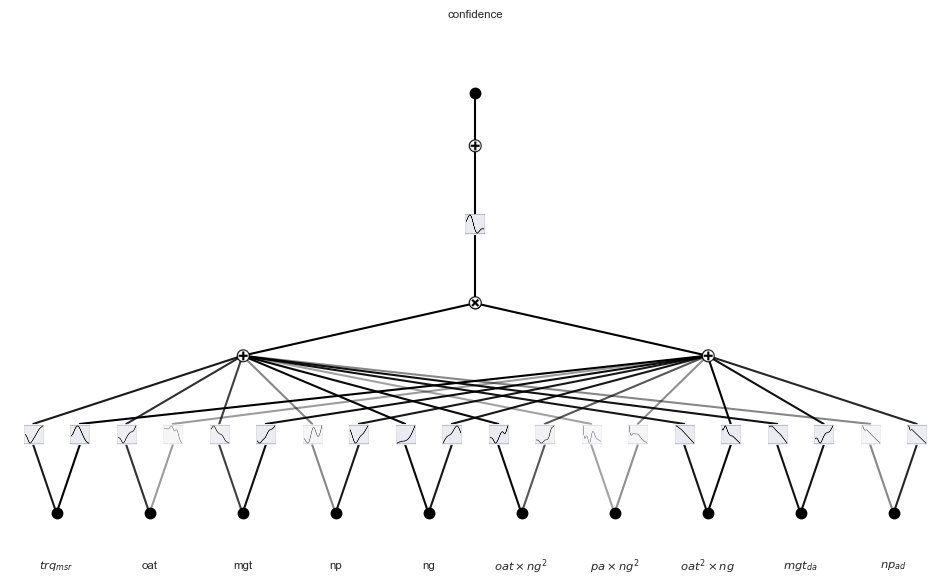

In [14]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$oat\\times ng^2$', '$pa\\times ng^2$', '$oat^2\\times ng$',
           '$mgt_{da}$', '$np_{ad}$', '$trq_{mrg}$']
pyKANClass.model.plot(scale=0.75, in_vars=in_vars, out_vars=['confidence'], varscale=0.275, figsize_base=(16, 10))

In [31]:
pyKANReg.eval()
labels = torch.tensor([])

for i in range(math.ceil(len(classification_x) / 8192)):
    x = classification_x[i * 8192:min(len(classification_x), (i + 1) * 8192)]
    x = torch.tensor(x.values, dtype=torch.float32, device=device)
    confidence = pyKANClass(x)
    labels = torch.cat((labels, (torch.sigmoid(confidence) > 0.5).int().cpu()))
labels = pd.Series(labels.squeeze())

# Plotting 3D PCA on valid/test set

C:\Users\MrPio\AppData\Local\Temp\ipykernel_32928\2282782962.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


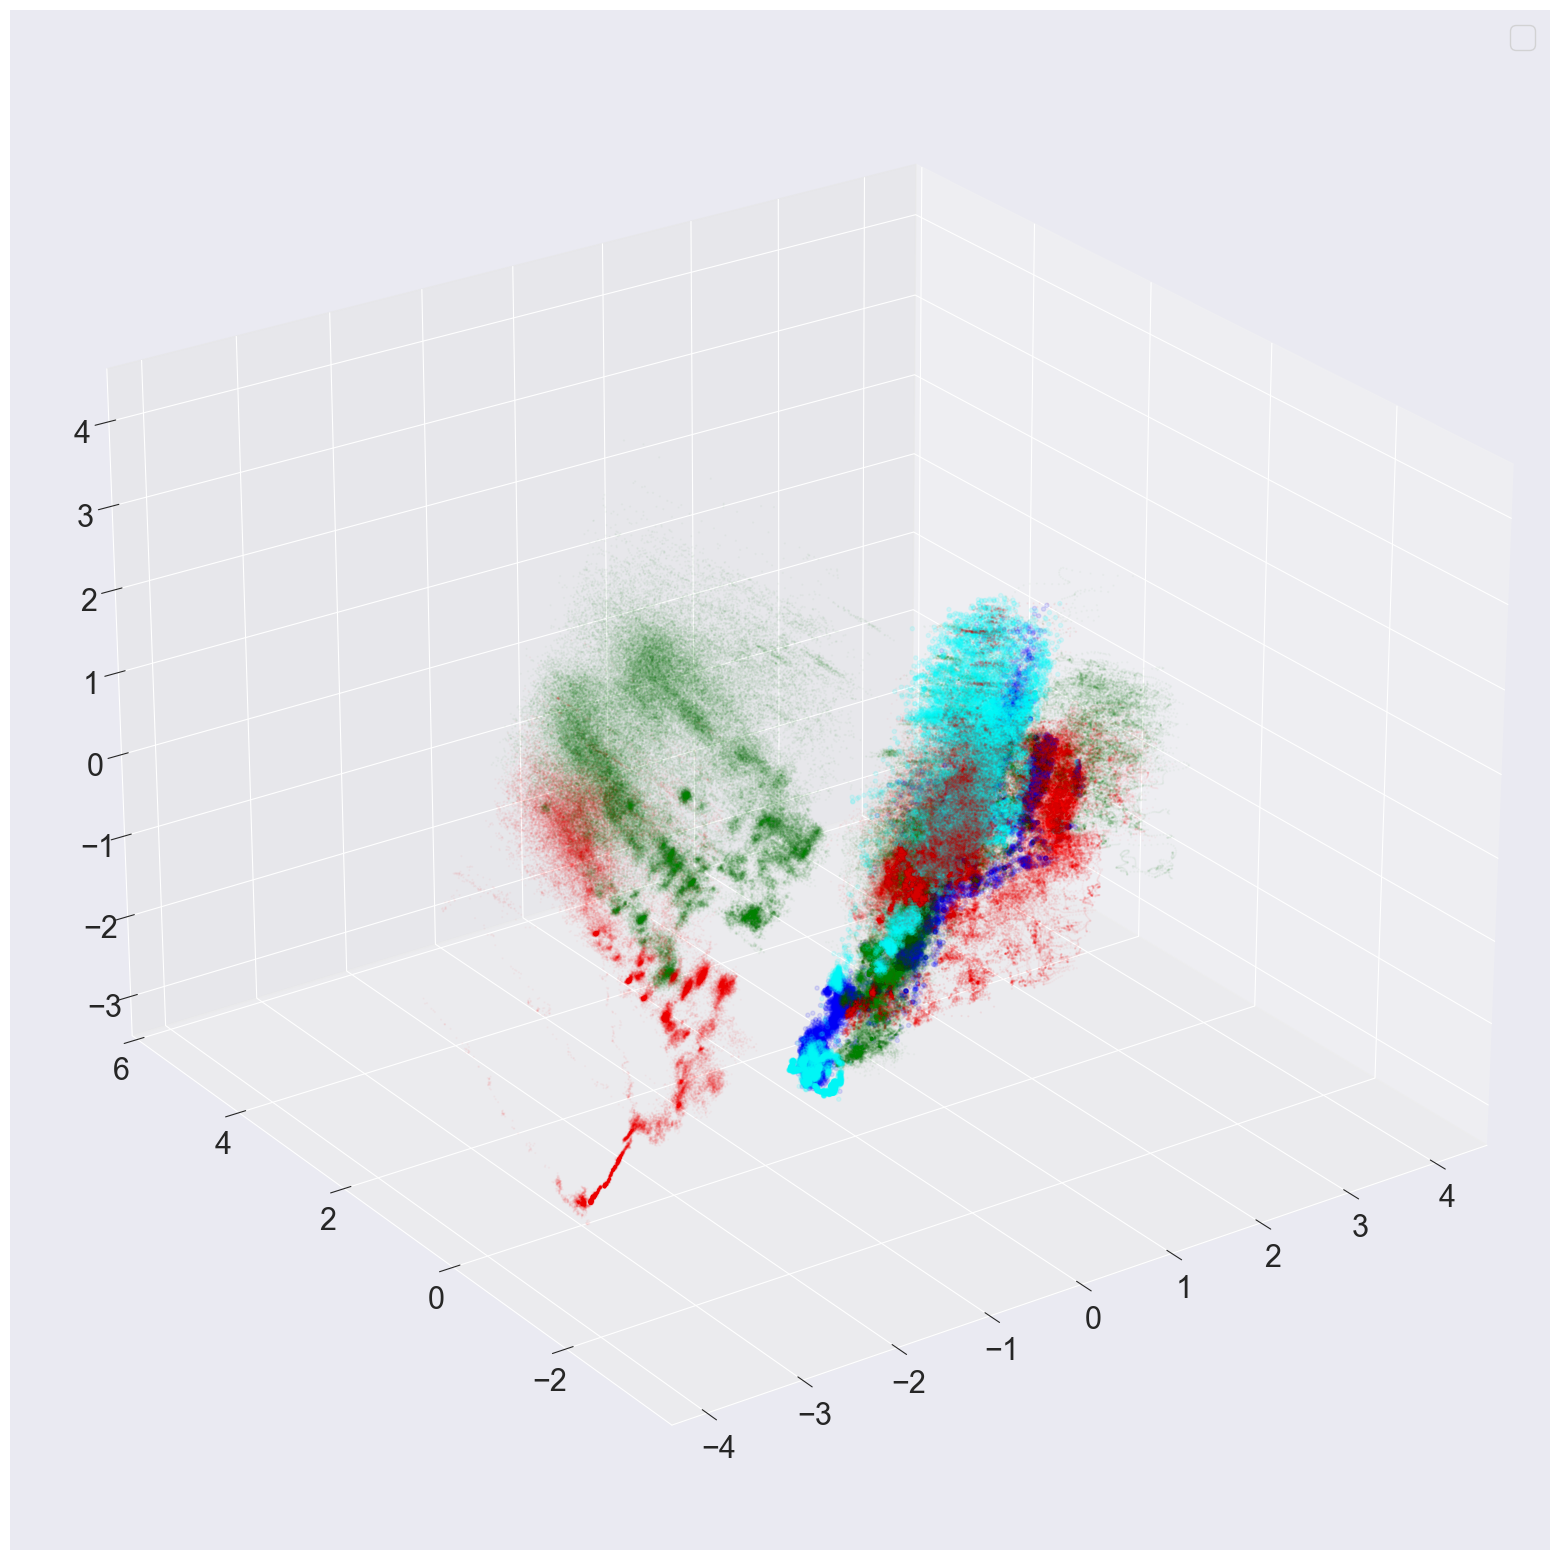

In [66]:
ax = plot_3d_pca(train_x[:], train_loadings, train_y['faulty'].values[:], scale=1, alpha=0.025)
plot_3d_pca(valid_test_x, train_loadings, labels, c={0: 'cyan', 1: 'blue'}, ax=ax, alpha=0.1)
plt.show()

In [72]:
pd.DataFrame({'faulty': labels, 'trq_margin': trq_margin_pred, 'trq_target': trq_target_pred}).to_csv(
    'valid_test_labels.csv', index=False)